#  Genre Popularity and Engagement Over Time

I wanted to explore comparing two different ways of understanding genre importance on Steam: how often genres appear in yearly releases, and how much player attention those genres seem to receive. The broader goal is to move past a simple count of games and toward a comparison between platform output and player engagement.

## Working Research Question
How has the relationship between genre release share and genre engagement share on Steam changed over time, and which genres appear to overperform or underperform relative to their release volume?

## Why this matters
If we only count how many games belong to each genre, we learn what kinds of games are being released most often. But that does not tell us whether those genres are also attracting proportionate player attention. By adding an engagement measure, this notebook asks whether the genres that dominate supply are also the ones that dominate attention.

Steam genres are not just technical labels but cultural categories that organize how games are produced, marketed, and discovered. By comparing the share of yearly releases in each genre to a rough engagement share based on playtime and reviews, this project examines where the platform’s output and player attention align—or fail to align. This helps reveal which kinds of games are oversupplied relative to player interest and which are underrepresented despite strong engagement, raising questions about platform power, market saturation, and the cultural visibility of different play styles.


## 1. Preparing the dataset
We use pandas for data manipulation, ast for converting stringified lists into actual Python lists, matplotlib for charts, and pathlib for file paths.

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_path = Path('games_march2025_cleaned.csv')
games = pd.read_csv(data_path)
games.shape

C:\Users\Owner\AppData\Local\Temp\ipykernel_23696\1102322823.py:2: DtypeWarning: Columns (0,3,4,5,6,13,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,158,159,160,161,167,168,169,170,171,172,173,174,175,180,187) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(data_path)


(84705, 192)

## 3. Relevant columns
We focus on the columns needed for this notebook: game identity, release date, genres, playtime, and reviews.

In [3]:
games[['appid', 'name', 'release_date', 'genres', 'average_playtime_forever', 'num_reviews_total']].head()

,appid,name,release_date,genres,average_playtime_forever,num_reviews_total
0,730,Counter-Strike 2,8/21/2012,"['Action', 'Free To Play']",33189,8632939
1,578080,PUBG: BATTLEGROUNDS,12/21/2017,"['Action', 'Adventure', 'Massively Multiplayer...",0,2513842
2,570,Dota 2,7/9/2013,"['Action', 'Strategy', 'Free To Play']",43031,2452595
3,271590,Grand Theft Auto V Legacy,4/13/2015,"['Action', 'Adventure']",19323,1803832
4,359550,Tom Clancy's Rainbow Six® Siege,12/1/2015,['Action'],14204,1168020


### Why these columns matter
- `release_date` gives us a time axis.
- `genres` defines the cultural categories we want to compare.
- `average_playtime_forever` gives a rough sense of how much time players spend with a game.
- `num_reviews_total` gives a rough sense of how many players engaged enough to leave feedback.
Together, these fields let us compare genre abundance with genre attention.

## 4. Parse release dates and create release year
To compare genres over time, we need a clean year variable. This converts messy date strings into proper datetimes and extracts the year.

This step was required as without a reliable year field, we cannot track change over time. Dropping rows with missing or invalid years is necessary because time-based comparisons depend on a clean chronological structure.

In [4]:
games['release_date_parsed'] = pd.to_datetime(games['release_date'], errors='coerce')
games['release_year'] = games['release_date_parsed'].dt.year
games[['release_date', 'release_date_parsed', 'release_year']].head()

,release_date,release_date_parsed,release_year
0,8/21/2012,2012-08-21,2012.0
1,12/21/2017,2017-12-21,2017.0
2,7/9/2013,2013-07-09,2013.0
3,4/13/2015,2015-04-13,2015.0
4,12/1/2015,2015-12-01,2015.0


In [5]:
games_years = games.dropna(subset=['release_year']).copy()
games_years['release_year'] = games_years['release_year'].astype(int)
games_years.shape

(83060, 194)

## 5. Clean the genres column
In this dataset, `genres` is stored as a string representation of a list. We need to convert it into a real Python list before we can count genres properly.

A single Steam game can belong to multiple genres. If genres stay packed inside one cell, we cannot accurately count how many Action, RPG, or Strategy games appear in a given year. Converting the string into a list is the first step toward making genre membership countable.

In [6]:
def parse_list_column(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

games_years['genres_list'] = games_years['genres'].apply(parse_list_column)
games_years[['genres', 'genres_list']].head()

,genres,genres_list
0,"['Action', 'Free To Play']","[Action, Free To Play]"
1,"['Action', 'Adventure', 'Massively Multiplayer...","[Action, Adventure, Massively Multiplayer, Fre..."
2,"['Action', 'Strategy', 'Free To Play']","[Action, Strategy, Free To Play]"
3,"['Action', 'Adventure']","[Action, Adventure]"
4,['Action'],[Action]


## 6. Build an engagement score

The one thing i wanted to account for was the engagement score. Just because a game is released doesn't mean it will be popular nor successful. A specific genre may have a large release share but a small engagement share, or vice versa. So, to tackle this issue this notebook uses a simple engagement proxy: `average_playtime_forever * num_reviews_total`. This is not a perfect measure of total success, but it gives a stronger approximation of player attention than release count alone.

In [7]:
games_years['average_playtime_forever'] = pd.to_numeric(games_years['average_playtime_forever'], errors='coerce').fillna(0)
games_years['num_reviews_total'] = pd.to_numeric(games_years['num_reviews_total'], errors='coerce').fillna(0)
games_years['engagement_score'] = games_years['average_playtime_forever'] * games_years['num_reviews_total']
games_years[['name', 'average_playtime_forever', 'num_reviews_total', 'engagement_score']].head()

,name,average_playtime_forever,num_reviews_total,engagement_score
0,Counter-Strike 2,33189.0,8632939.0,2.865186e+11
1,PUBG: BATTLEGROUNDS,0.0,2513842.0,0.000000e+00
2,Dota 2,43031.0,2452595.0,1.055376e+11
3,Grand Theft Auto V Legacy,19323.0,1803832.0,3.485545e+10
4,Tom Clancy's Rainbow Six® Siege,14204.0,1168020.0,1.659056e+10


### Why we use an engagement score
Release count tells us how many games are being made, but not how much attention they receive. Playtime alone captures intensity, while review count suggests a broader audience footprint. Multiplying them creates a rough proxy for genre-level attention. This is still imperfect, but it gives a more meaningful comparison than game counts alone.

### Limitation note
This score does not measure revenue, player count, or total aggregate hours exactly. It should be interpreted as a proxy for engagement, not as a perfect measure of commercial success.

## 7. Explode genres into long format
Each game can belong to multiple genres, so we transform the data from one row per game to one row per game-genre pair.
Exploding the genre list is crucial because it creates one row for each game-genre relationship. This makes it possible to count genres cleanly and sum engagement scores at the genre-year level. Without long format, the notebook could not compare genres systematically.

In [8]:
genre_long = games_years[['appid', 'name', 'release_year', 'genres_list', 'engagement_score']].explode('genres_list').rename(columns={'genres_list': 'genre'})
genre_long = genre_long.dropna(subset=['genre'])
genre_long.head()

,appid,name,release_year,genre,engagement_score
0,730,Counter-Strike 2,2012,Action,2.865186e+11
0,730,Counter-Strike 2,2012,Free To Play,2.865186e+11
1,578080,PUBG: BATTLEGROUNDS,2017,Action,0.000000e+00
1,578080,PUBG: BATTLEGROUNDS,2017,Adventure,0.000000e+00
1,578080,PUBG: BATTLEGROUNDS,2017,Massively Multiplayer,0.000000e+00


## 8. Calculate yearly genre release counts and proportions
Steam releases grow dramatically over time, so raw counts alone can be misleading. A genre may have more games in a later year simply because Steam as a whole has more releases. Release proportion corrects for this by asking: what share of that year's games belong to this genre?

In [9]:
genre_counts = genre_long.groupby(['release_year', 'genre']).size().reset_index(name='genre_count')
year_totals = games_years.groupby('release_year')['appid'].nunique().reset_index(name='total_games_year')
genre_release_trends = genre_counts.merge(year_totals, on='release_year', how='left')
genre_release_trends['release_proportion'] = genre_release_trends['genre_count'] / genre_release_trends['total_games_year']
genre_release_trends.head()

,release_year,genre,genre_count,total_games_year,release_proportion
0,1997,Action,1,1,1.0
1,1997,Indie,1,1,1.0
2,1999,Action,1,1,1.0
3,2001,Action,1,2,0.5
4,2001,Indie,1,2,0.5


## 9. Calculate yearly engagement share by genre
This is the key conceptual move in the notebook. Instead of only asking which genres are common, we ask which genres command attention. A genre can have a large release share but a small engagement share, or vice versa. That gap is what makes the analysis interesting.

In [10]:
genre_engagement = genre_long.groupby(['release_year', 'genre'], as_index=False)['engagement_score'].sum()
year_engagement_totals = genre_long.groupby('release_year', as_index=False)['engagement_score'].sum().rename(columns={'engagement_score': 'total_engagement_year'})
genre_engagement_trends = genre_engagement.merge(year_engagement_totals, on='release_year', how='left')
genre_engagement_trends['engagement_proportion'] = genre_engagement_trends['engagement_score'] / genre_engagement_trends['total_engagement_year']
genre_engagement_trends.head()

,release_year,genre,engagement_score,total_engagement_year,engagement_proportion
0,1997,Action,0.0,0.0,NaN
1,1997,Indie,0.0,0.0,NaN
2,1999,Action,1562162.0,1562162.0,1.0
3,2001,Action,8216094.0,16432188.0,0.5
4,2001,Indie,0.0,16432188.0,0.0


## 10. Merge release and engagement views
This creates one comparison table where release share and engagement share can be studied side by side.

In [11]:
genre_comparison = genre_release_trends.merge(genre_engagement_trends[['release_year', 'genre', 'engagement_score', 'total_engagement_year', 'engagement_proportion']], on=['release_year', 'genre'], how='left')
genre_comparison.head()

,release_year,genre,genre_count,total_games_year,release_proportion,engagement_score,total_engagement_year,engagement_proportion
0,1997,Action,1,1,1.0,0.0,0.0,NaN
1,1997,Indie,1,1,1.0,0.0,0.0,NaN
2,1999,Action,1,1,1.0,1562162.0,1562162.0,1.0
3,2001,Action,1,2,0.5,8216094.0,16432188.0,0.5
4,2001,Indie,1,2,0.5,0.0,16432188.0,0.0


## 11. Focus on selected genres
To keep the visualizations readable, we focus first on a smaller group of widely recognizable genres.

In [12]:
selected_genres = ['Action', 'Adventure', 'RPG', 'Strategy', 'Simulation', 'Indie', 'Casual']
selected_comparison = genre_comparison[genre_comparison['genre'].isin(selected_genres)].copy()
selected_comparison.head()

,release_year,genre,genre_count,total_games_year,release_proportion,engagement_score,total_engagement_year,engagement_proportion
0,1997,Action,1,1,1.0,0.0,0.0,NaN
1,1997,Indie,1,1,1.0,0.0,0.0,NaN
2,1999,Action,1,1,1.0,1562162.0,1562162.0,1.0
3,2001,Action,1,2,0.5,8216094.0,16432188.0,0.5
4,2001,Indie,1,2,0.5,0.0,16432188.0,0.0


## 12. Plot release share over time

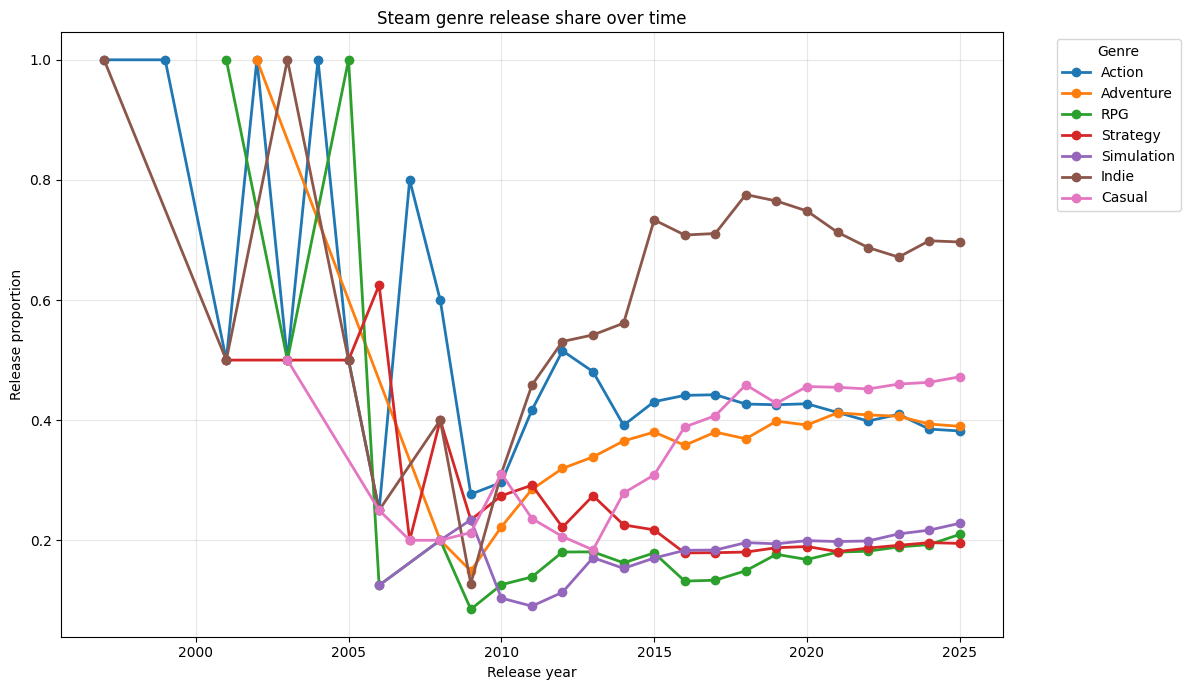

In [13]:
plt.figure(figsize=(12, 7))
for genre in selected_genres:
    subset = selected_comparison[selected_comparison['genre'] == genre].sort_values('release_year')
    plt.plot(subset['release_year'], subset['release_proportion'], marker='o', linewidth=2, label=genre)
plt.title('Steam genre release share over time')
plt.xlabel('Release year')
plt.ylabel('Release proportion')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation prompt
After running this chart, note which genres appear consistently common and which grow or decline. This chart describes the structure of Steam's yearly output, not necessarily which genres are most successful.

## 13. Plot engagement share over time

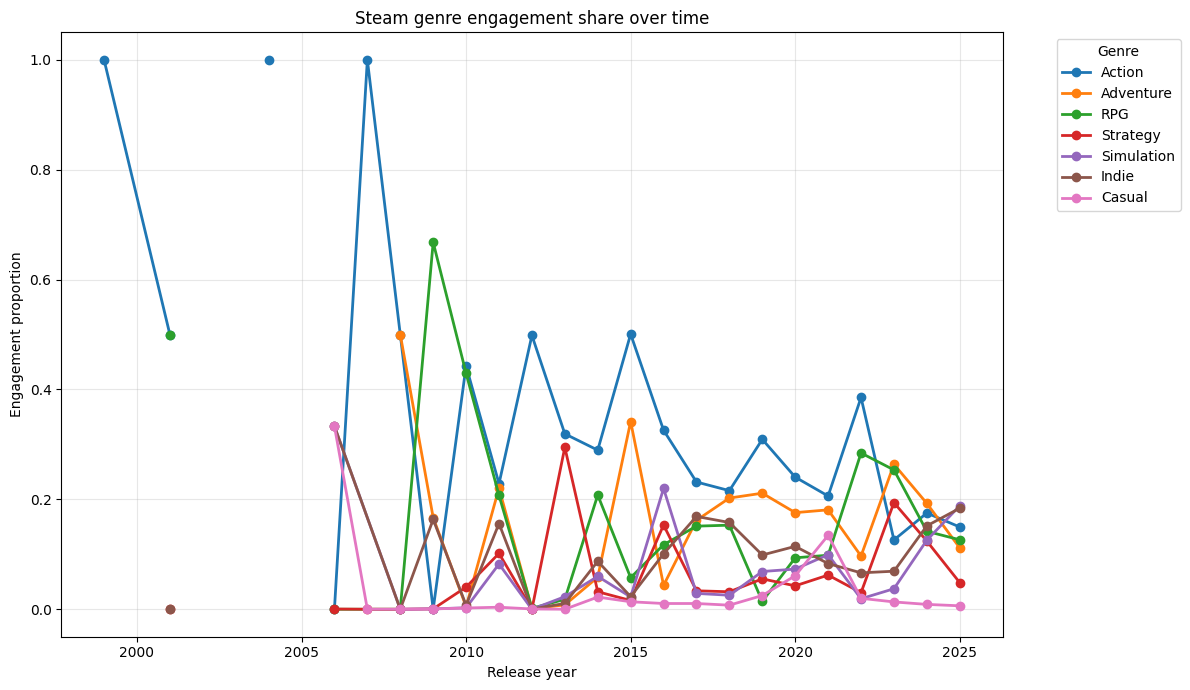

In [14]:
plt.figure(figsize=(12, 7))
for genre in selected_genres:
    subset = selected_comparison[selected_comparison['genre'] == genre].sort_values('release_year')
    plt.plot(subset['release_year'], subset['engagement_proportion'], marker='o', linewidth=2, label=genre)
plt.title('Steam genre engagement share over time')
plt.xlabel('Release year')
plt.ylabel('Engagement proportion')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation prompt
After running this chart, compare it mentally to the release-share chart. Do the genres that appear most often also dominate engagement? Which genres seem to attract disproportionately high or low attention?

## 14. Compare release share and engagement share for the latest year
This gives a simple year-specific snapshot of genre overperformance and underperformance.

In [15]:
latest_year = selected_comparison['release_year'].max()
latest_view = selected_comparison[selected_comparison['release_year'] == latest_year][['genre', 'release_proportion', 'engagement_proportion']].sort_values('release_proportion', ascending=False)
latest_view

,genre,release_proportion,engagement_proportion
389,Indie,0.696619,0.183900
383,Casual,0.472118,0.006281
380,Adventure,0.389772,0.111751
379,Action,0.381971,0.149647
394,Simulation,0.228258,0.188485
392,RPG,0.209766,0.126408
397,Strategy,0.194741,0.048386


### Interpretation 

Indie and Casual games dominate new releases in the latest year, but they capture a much smaller share of engagement, suggesting the store is oversupplied with these genres relative to how much attention players actually give them.

By contrast, Simulation, Action, Adventure, RPG, and Strategy account for a modest share of yearly releases but earn a disproportionate share of engagement, implying that players concentrate their time in fewer, higher-impact titles in these genres.

Put differently, the market is saturated with Indie and Casual launches, while player attention is tilted toward more complex or long-form genres such as Simulation, Action, and RPG, which overperform their production volume.

## 15. Save outputs for later notebooks

In [17]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)
games_years[['appid', 'name', 'release_year', 'genres', 'genres_list', 'average_playtime_forever', 'num_reviews_total', 'engagement_score']].to_csv(output_dir / 'steam_games_year_genres_engagement_base.csv', index=False)
genre_long.to_csv(output_dir / 'steam_games_genres_engagement_long.csv', index=False)
print('Saved release and engagement outputs to output/')

Saved release and engagement outputs to output/


## 16. Reflection 
This project was a analysis of Steam genres. By converting release dates into release years, cleaning the genre field, and reshaping the data into a long format, I created a reliable foundation for studying how Steam genres change over time.

A major takeaway from this step is that raw counts alone are not enough to interpret platform trends. Because the number of Steam releases grows heavily across years, using genre proportions gives a more meaningful view of whether a genre is actually becoming more or less common relative to the size of the market.

This step was also important because many Steam games belong to more than one genre. Exploding the genre lists made it possible to measure genre presence more accurately and avoid treating combined genre labels as a single category.

Overall, this notebook did more than clean data; it prepared the project for deeper interpretation. The saved outputs can now be used to visualize which genres stay stable, which increase over time, which decline